In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
%matplotlib inline

In [3]:
words = open('names.txt', 'r').read().splitlines()
words[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [4]:
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}

In [24]:
X,Y = [], []
block_size = 3
for w in words:
    context = [0] * block_size
    #print(w)
    for ch in w + '.':
        ix = stoi[ch]
        X.append(context)
        Y.append(ix)
        #print(''.join(itos[i] for i in context) , '--->', itos[ix])
        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [ ]:
# INITIALISATION BLOCK
C = torch.randn((27,2))
W1 = torch.randn((6,100))
B1 = torch.randn((100))
W2 = torch.randn((100,27))
B2 = torch.randn((27))
parameters = [C , W1, B1, W2, B2]
for p in parameters:
    p.requires_grad = True

In [ ]:
# ACTUAL TRAINING LOOP YAYAYAYYAAY
for _ in range(20):
    #---FORWARD PASS---
    emb = C[X]
    h = torch.tanh(emb.view(-1,6) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,Y)
    print(loss.item())
    #---BACKWARD PASS---
    for p in parameters:
        p.grad = None
    loss.backward()

    #---UPDATING---
    for p in parameters:
        p.data += -0.3 * p.grad

17.160493850708008
14.876197814941406
12.827481269836426
11.520684242248535
10.466434478759766
9.5674409866333
8.790630340576172
8.167856216430664
7.550930500030518
7.081661701202393
6.694273471832275
6.33331298828125
6.022046089172363
5.730253219604492
5.4910888671875
5.266958236694336
5.089633941650391
4.904441833496094
4.766080379486084
4.622531414031982


In [ ]:
print(logits.max(1) , Y) #shows how close the predictions actually are

torch.return_types.max(
values=tensor([ 7.5279,  7.3765,  7.9767,  5.7911,  8.1640,  9.9226,  9.5220, 11.4499,
        11.9686, 13.1644,  8.6488,  6.6861,  9.4403,  8.2097,  8.8200,  8.9196,
         9.3214,  8.8057,  8.8469,  7.3659, 11.4499, 11.4499,  7.4037,  9.0956,
        11.4499,  9.0436,  8.9198,  8.1316, 11.1714, 11.0812,  8.6090, 11.4499],
       grad_fn=<MaxBackward0>),
indices=tensor([ 8,  9, 20, 24,  0,  0,  0, 25, 25, 25,  0,  5,  0,  0,  1,  9, 19,  1,
        25,  5, 25, 25,  0,  0, 25,  0,  0,  0, 25, 25,  0, 25])) tensor([ 5, 13, 13,  ..., 26, 24,  0])


In [28]:
# HOW TO DETERMINE A GOOD LEARNING RATE:
x = torch.linspace(0.001 , 1 , 1000)
lre = torch.linspace(-3, 0 , 1000) # WE USE THIS TO STEP EXPONENTIALLY INSTEAD OF LINEARLY
lrs = 10 ** lre
lri , lossi = [] , []
for i in range(1000):
    #---MINIBATCHING---
    ix = torch.randint(0, X.shape[0], (32,))
    #---FORWARD PASS---
    emb = C[X[ix]]
    h = torch.tanh(emb.view(-1,6) @ W1 + B1)
    logits = h @ W2 + B2
    loss = F.cross_entropy(logits,Y[ix])
    #print(loss.item())

    #---BACKWARD PASS---
    for p in parameters:
        p.grad = None
    loss.backward()

    #---UPDATING---
    lr = lrs[i]
    for p in parameters:
        p.data += -lr * p.grad

     #---TRACKING STATS--- 
    lri.append(lre[i])
    lossi.append(loss.item())

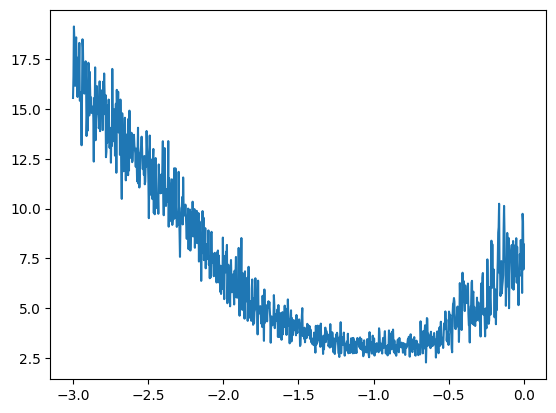

In [30]:
plt.plot(lri ,lossi) #THIS SHOWS THAT A GOOD LEARNING RATE IS AROUND -1